In [1]:
from icecube import icetray, dataio, dataclasses, LeptonInjector
import math
from icecube.dataclasses import ModuleKey
from icecube.icetray import OMKey

In [2]:
# DATA_PATH = "/home/kbas/scratch/String340MC_pone_offline_version3_plus/Muon_PMT_Response/muon_cls_000.i3.gz"
DATA_PATH = "/home/kbas/scratch/String340MC_pone_offline_version3_plus/Electron_PMT_Response/electron_gen_000.i3.gz"
data_file = dataio.I3File(DATA_PATH)


In [3]:
tray_info_1 = data_file.pop_frame()
print(tray_info_1)


[ I3Frame  (TrayInfo):
  '2026-07-07T18:08:02' [TrayInfo] ==> I3TrayInfo (12122)
]



In [4]:
tray_info_2 = data_file.pop_frame()
print(tray_info_2)


[ I3Frame  (TrayInfo):
  '2025-04-23T20:33:51.040646' [TrayInfo] ==> I3TrayInfo (10160)
]



In [5]:
daq_frame = data_file.pop_daq()



In [6]:
print(daq_frame)

[ I3Frame  (DAQ):
  'Accepted_PulseMap_102_String' [DAQ] ==> I3Map<OMKey, vector<I3MCPE> > (41)
  'Accepted_PulseMap_160_String' [DAQ] ==> I3Map<OMKey, vector<I3MCPE> > (41)
  'Accepted_PulseMap_340String' [DAQ] ==> I3Map<OMKey, vector<I3MCPE> > (41)
  'EventProperties' [DAQ] ==> LeptonInjector::BasicEventProperties (140)
  'I3EventHeader' [DAQ] ==> I3EventHeader (99)
  'I3MCTree' [DAQ] ==> TreeBase::Tree<I3Particle, I3ParticleID, i3hash<I3ParticleID> > (422)
  'I3MCTree_RNGState' [DAQ] ==> I3GSLRandomServiceState (87)
  'I3MCTree_postprop' [DAQ] ==> TreeBase::Tree<I3Particle, I3ParticleID, i3hash<I3ParticleID> > (422)
  'I3Photons' [DAQ] ==> I3Map<ModuleKey, I3Vector<I3CompressedPhoton> > (53)
  'MMCTrackList' [DAQ] ==> I3Vector<I3MMCTrack> (40)
  'Noise_Dark_340_String' [DAQ] ==> I3Map<OMKey, vector<I3MCPE> > (51494)
  'Noise_K40_340_String' [DAQ] ==> I3Map<OMKey, vector<I3MCPE> > (165340)
  'PMT_Response_102_String' [DAQ] ==> I3Map<OMKey, vector<I3RecoPulse> > (62095)
  'PMT_Respons

## Find a DAQ Frame Triggered in All Noisy and Nonoise Geometries

This section re-opens the selected PMT response file from `DATA_PATH` and scans DAQ frames until it finds the first frame where all six trigger flags are equal to `1`: noisy/nonoise for 102, 160, and 340 strings. The matched frame is stored as `frame_all_triggered` for the plots below.

In [7]:
ALL_TRIGGER_KEYS = [
    "triggered_noisy_102_string",
    "triggered_noisy_160_string",
    "triggered_noisy_340_string",
    "triggered_nonoise_102_string",
    "triggered_nonoise_160_string",
    "triggered_nonoise_340_string",
]

def scalar_from_frame_value(value):
    if hasattr(value, "value"):
        return value.value
    return value

def frame_trigger_value(frame, key):
    if key not in frame:
        return None
    return float(scalar_from_frame_value(frame[key]))

def frame_has_all_triggers(frame):
    return all(frame_trigger_value(frame, key) == 1.0 for key in ALL_TRIGGER_KEYS)

frame_all_triggered = None
frame_all_triggered_index = None

scan_file = dataio.I3File(DATA_PATH, "r")
daq_index = 0
try:
    while scan_file.more():
        frame = scan_file.pop_frame()
        if frame.Stop != icetray.I3Frame.DAQ:
            continue

        if frame_has_all_triggers(frame):
            frame_all_triggered = frame
            frame_all_triggered_index = daq_index
            break

        daq_index += 1
finally:
    scan_file.close()

if frame_all_triggered is None:
    raise RuntimeError(f"No DAQ frame found with all trigger keys equal to 1 in {DATA_PATH}")

print(f"Found all-triggered DAQ frame at daq_index={frame_all_triggered_index}")
if "I3EventHeader" in frame_all_triggered:
    header = frame_all_triggered["I3EventHeader"]
    print(f"RunID={header.run_id} EventID={header.event_id} SubEventID={header.sub_event_id}")

for key in ALL_TRIGGER_KEYS:
    print(f"{key}: {frame_trigger_value(frame_all_triggered, key)}")


Found all-triggered DAQ frame at daq_index=35
RunID=0 EventID=36 SubEventID=0
triggered_noisy_102_string: 1.0
triggered_noisy_160_string: 1.0
triggered_noisy_340_string: 1.0
triggered_nonoise_102_string: 1.0
triggered_nonoise_160_string: 1.0
triggered_nonoise_340_string: 1.0


## Plot PMT Response Pulse Times and Charges

For the selected `frame_all_triggered`, plot the six PMT response maps in one vertical canvas. Each panel uses its corresponding trigger time as a vertical dashed line.

In [8]:
import numpy as np
import matplotlib.pyplot as plt

PMT_RESPONSE_PLOTS = [
    {
        "label": "Nonoise 102 string",
        "map_key": "PMT_Response_nonoise_102_String",
        "trigger_time_key": "trigger_time_nonoise_102_string",
    },
    {
        "label": "Noisy 102 string",
        "map_key": "PMT_Response_102_String",
        "trigger_time_key": "trigger_time_noisy_102_string",
    },
    {
        "label": "Nonoise 160 string",
        "map_key": "PMT_Response_nonoise_160_String",
        "trigger_time_key": "trigger_time_nonoise_160_string",
    },
    {
        "label": "Noisy 160 string",
        "map_key": "PMT_Response_160_String",
        "trigger_time_key": "trigger_time_noisy_160_string",
    },
    {
        "label": "Nonoise 340 string",
        "map_key": "PMT_Response_nonoise_340_String",
        "trigger_time_key": "trigger_time_nonoise_340_string",
    },
    {
        "label": "Noisy 340 string",
        "map_key": "PMT_Response_340_String",
        "trigger_time_key": "trigger_time_noisy_340_string",
    },
]

def pulse_times_and_charges(frame, map_key):
    if map_key not in frame:
        raise KeyError(f"Missing pulse map: {map_key}")

    times = []
    charges = []
    pmt_numbers = []
    pulse_map = frame[map_key]

    for omkey, pulses in pulse_map.items():
        try:
            pmt_number = omkey.om
        except AttributeError:
            pmt_number = np.nan

        for pulse in pulses:
            times.append(float(pulse.time))
            charges.append(float(pulse.charge))
            pmt_numbers.append(pmt_number)

    return np.asarray(times), np.asarray(charges), np.asarray(pmt_numbers)

def get_trigger_time(frame, trigger_time_key):
    if trigger_time_key not in frame:
        return np.nan
    return float(scalar_from_frame_value(frame[trigger_time_key]))


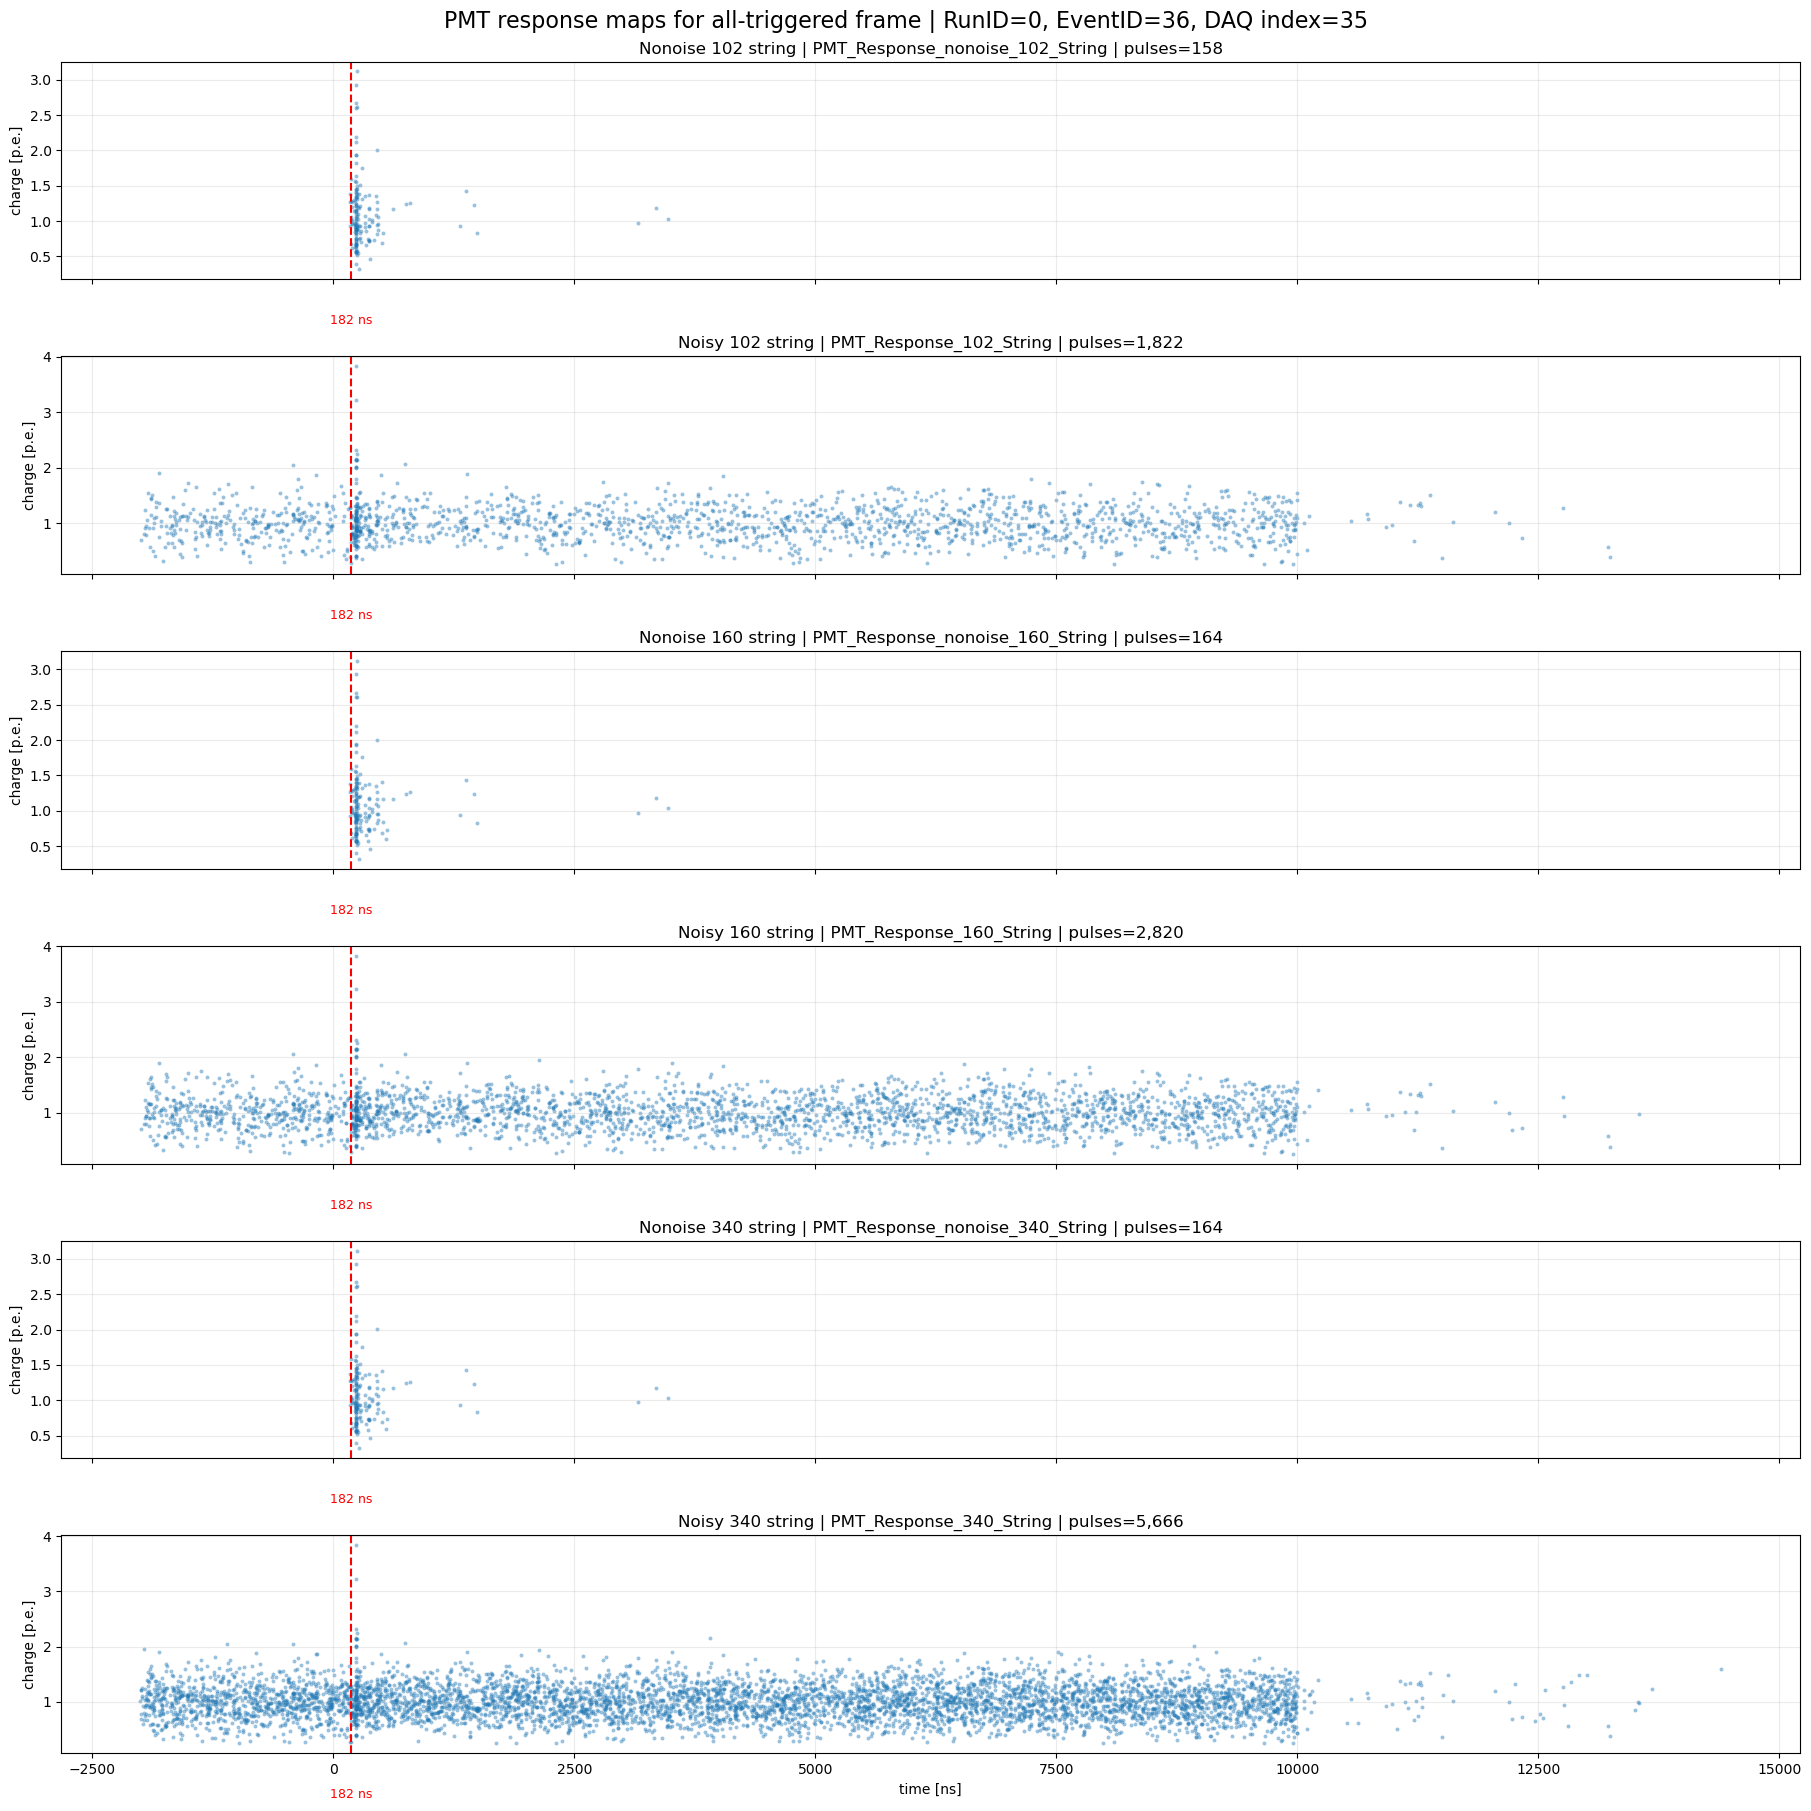

In [9]:
fig, axes = plt.subplots(
    nrows=len(PMT_RESPONSE_PLOTS),
    ncols=1,
    figsize=(18, 18),
    sharex=True,
    constrained_layout=True,
)

if "I3EventHeader" in frame_all_triggered:
    header = frame_all_triggered["I3EventHeader"]
    title_suffix = f"RunID={header.run_id}, EventID={header.event_id}, DAQ index={frame_all_triggered_index}"
else:
    title_suffix = f"DAQ index={frame_all_triggered_index}"

for ax, spec in zip(axes, PMT_RESPONSE_PLOTS):
    times, charges, pmt_numbers = pulse_times_and_charges(frame_all_triggered, spec["map_key"])
    trigger_time = get_trigger_time(frame_all_triggered, spec["trigger_time_key"])

    if len(times) > 0:
        ax.scatter(times, charges, s=8, alpha=0.45, linewidths=0)
    else:
        ax.text(0.5, 0.5, "No pulses", transform=ax.transAxes, ha="center", va="center")

    if np.isfinite(trigger_time) and trigger_time >= 0:
        ax.axvline(trigger_time, color="red", linestyle="--", linewidth=1.5)
        ax.text(
            trigger_time,
            -0.16,
            f"{trigger_time:.0f} ns",
            transform=ax.get_xaxis_transform(),
            ha="center",
            va="top",
            fontsize=9,
            color="red",
            clip_on=False,
        )

    ax.set_ylabel("charge [p.e.]")
    ax.grid(True, alpha=0.25)
    ax.set_title(f"{spec['label']} | {spec['map_key']} | pulses={len(times):,}")

axes[-1].set_xlabel("time [ns]")
fig.suptitle(f"PMT response maps for all-triggered frame | {title_suffix}", fontsize=16)
plt.show()


## Sanity Check: 102/160 String Subselection Geometry

We want to check whether the 102-string and 160-string PMT response subselections look geometrically sensible. This section scans every DAQ frame in the selected `DATA_PATH`, collects the total unique string IDs seen in `PMT_Response_160_String` and `PMT_Response_102_String`, then plots those strings using the full 340-string GCD XY coordinates.

In [10]:
from pathlib import Path
import importlib.util

PATHS_PY = Path("/project/def-nahee/kbas/Graphnet-Applications/Metadata/paths.py")
spec = importlib.util.spec_from_file_location("metadata_paths", PATHS_PY)
metadata_paths = importlib.util.module_from_spec(spec)
spec.loader.exec_module(metadata_paths)

FULL_GCD_PATH = metadata_paths.GCD["340StringMC"]

def collect_unique_strings_from_pmt_response(data_path, map_key):
    unique_strings = set()
    n_daq = 0
    n_with_map = 0

    i3_file = dataio.I3File(str(data_path), "r")
    try:
        while i3_file.more():
            frame = i3_file.pop_frame()
            if frame.Stop != icetray.I3Frame.DAQ:
                continue

            n_daq += 1
            if map_key not in frame:
                continue

            n_with_map += 1
            for omkey in frame[map_key].keys():
                unique_strings.add(int(omkey.string))
    finally:
        i3_file.close()

    return sorted(unique_strings), n_daq, n_with_map

def string_xy_from_gcd(gcd_path):
    geometry = None
    gcd_file = dataio.I3File(str(gcd_path), "r")
    try:
        while gcd_file.more():
            frame = gcd_file.pop_frame()
            if "I3Geometry" in frame:
                geometry = frame["I3Geometry"]
                break
    finally:
        gcd_file.close()

    if geometry is None:
        raise RuntimeError(f"No I3Geometry found in {gcd_path}")

    positions_by_string = {}
    for omkey, omgeo in geometry.omgeo.items():
        string_id = int(omkey.string)
        pos = omgeo.position
        positions_by_string.setdefault(string_id, []).append((float(pos.x), float(pos.y)))

    string_xy = {}
    for string_id, xy_values in positions_by_string.items():
        xy = np.asarray(xy_values, dtype=float)
        string_xy[string_id] = (float(xy[:, 0].mean()), float(xy[:, 1].mean()))

    return string_xy

response_map_keys = {
    "160_string": "PMT_Response_160_String",
    "102_string": "PMT_Response_102_String",
}

response_string_info = {}
for label, map_key in response_map_keys.items():
    strings, n_daq_frames, n_daq_with_map = collect_unique_strings_from_pmt_response(DATA_PATH, map_key)
    response_string_info[label] = {
        "map_key": map_key,
        "strings": strings,
        "string_set": set(strings),
        "n_daq_frames": n_daq_frames,
        "n_daq_with_map": n_daq_with_map,
    }

full_gcd_string_xy = string_xy_from_gcd(FULL_GCD_PATH)
full_gcd_string_set = set(full_gcd_string_xy)

print(f"DATA_PATH: {DATA_PATH}")
print(f"Full 340-string GCD strings: {len(full_gcd_string_set):,}")
for label, info in response_string_info.items():
    response_set = info["string_set"]
    print()
    print(f"{label} | {info['map_key']}")
    print(f"DAQ frames scanned: {info['n_daq_frames']:,}")
    print(f"DAQ frames with map: {info['n_daq_with_map']:,}")
    print(f"Unique strings seen: {len(response_set):,}")
    print(info["strings"])
    print(f"Strings missing from full GCD: {sorted(response_set - full_gcd_string_set)}")


DATA_PATH: /home/kbas/scratch/String340MC_pone_offline_version3_plus/Electron_PMT_Response/electron_gen_000.i3.gz
Full 340-string GCD strings: 340

160_string | PMT_Response_160_String
DAQ frames scanned: 200
DAQ frames with map: 200
Unique strings seen: 160
[29, 30, 31, 32, 34, 35, 36, 37, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 61, 62, 63, 64, 65, 66, 67, 68, 69, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 213, 214, 215, 216, 217, 218, 219, 220, 221, 222, 223, 224, 225, 226, 232, 233, 234, 235, 236, 237, 238, 239, 240, 241, 242, 243, 244, 245, 250, 251, 253, 254, 255, 256, 257, 258,

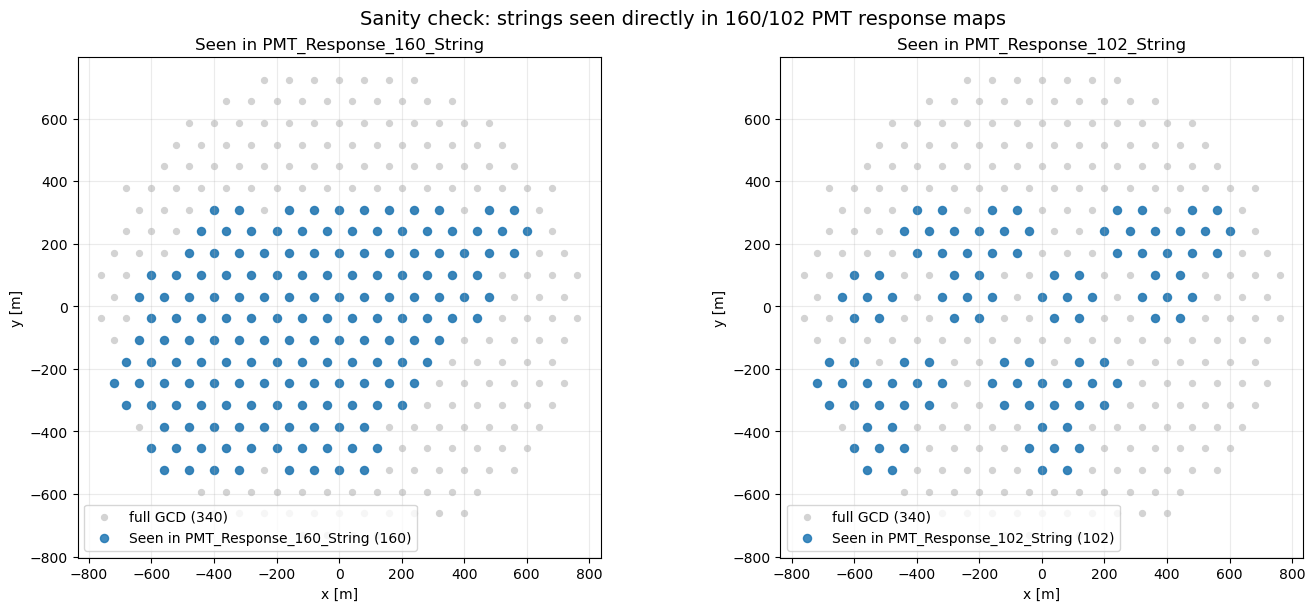

In [11]:
def xy_arrays(string_xy, string_ids):
    points = [string_xy[string_id] for string_id in sorted(string_ids) if string_id in string_xy]
    if not points:
        return np.asarray([]), np.asarray([])
    points = np.asarray(points, dtype=float)
    return points[:, 0], points[:, 1]

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 6), constrained_layout=True)

plot_specs = [
    (axes[0], "Seen in PMT_Response_160_String", response_string_info["160_string"]["string_set"]),
    (axes[1], "Seen in PMT_Response_102_String", response_string_info["102_string"]["string_set"]),
]

for ax, title, response_strings in plot_specs:
    x_all, y_all = xy_arrays(full_gcd_string_xy, full_gcd_string_set)
    x_response, y_response = xy_arrays(full_gcd_string_xy, response_strings)

    ax.scatter(x_all, y_all, s=18, color="lightgray", label=f"full GCD ({len(full_gcd_string_set)})")
    ax.scatter(x_response, y_response, s=34, color="tab:blue", alpha=0.85, label=f"{title} ({len(response_strings)})")

    ax.set_title(title)
    ax.set_xlabel("x [m]")
    ax.set_ylabel("y [m]")
    ax.set_aspect("equal", adjustable="box")
    ax.grid(True, alpha=0.25)
    ax.legend(loc="best")

fig.suptitle("Sanity check: strings seen directly in 160/102 PMT response maps", fontsize=14)
plt.show()
